# Lezione 04 - Notebook docente

## Perdita obbligazionaria condizionata a regimi di tasso

Questo notebook docente implementa il **caso aula** della Lezione 04: una procedura Monte Carlo gerarchica per analizzare la perdita di un portafoglio obbligazionario a tasso fisso in presenza di regimi informativi del mercato dei tassi.

La domanda quantitativa e':

$$
\text{Qual e' la distribuzione della perdita } L
\text{ e come cambia la perdita attesa condizionando sui diversi regimi di tasso?}
$$

Il notebook mantiene la specifica fissata nella Scheda Caso Aula:

- gli eventi informativi sono $A_1,A_2,A_3$;
- non viene introdotta una variabile casuale discreta teorica ausiliaria;
- lo shock di rendimento e' $\Delta y$;
- la perdita e' costruita mediante l'approssimazione lineare di duration:

$$
L = D V_0 \Delta y.
$$

Il notebook ha funzione docente: rende espliciti input, output, controlli e lettura didattica di ciascuna tappa.

## Flusso logico-teorico risolutivo

| Passo | Finalita' | Formula / proprieta' | Output collegato |
|---:|---|---|---|
| 1 | Collegare perdita e shock di rendimento | $L=D V_0\Delta y$ | dataset simulato con $\Delta y$ e $L$ |
| 2 | Tradurre la soglia monetaria in soglia di shock | $L>\ell \Longleftrightarrow \Delta y>\ell/(D V_0)$ | soglia implicita $\Delta y^\star$ |
| 3 | Rappresentare l'informazione | $\Omega=A_1\cup A_2\cup A_3$ | tabella eventi e frequenze |
| 4 | Simulare la distribuzione condizionata | $\Delta y\mid A_g\sim\mathcal{N}(\mu_g,\sigma_g^2)$ | shock simulati per regime |
| 5 | Analizzare la distribuzione non condizionata | media, quantili, probabilita' di superamento | tabelle e grafici globali |
| 6 | Analizzare il condizionamento | $\mathbb{E}[L\mid A_g]$ | medie condizionate |
| 7 | Costruire il valore atteso condizionato rispetto a $\mathcal{G}$ | $\mathbb{E}[L\mid\mathcal{G}]=\sum_g \mathbb{E}[L\mid A_g]\mathbf{1}_{A_g}$ | variabile a gradini |
| 8 | Verificare la coerenza aggregata | $\mathbb{E}[L]=\sum_g\mathbb{P}(A_g)\mathbb{E}[L\mid A_g]$ | controllo del valore atteso totale |

## Scomposizione operativa in tappe

| Tappa | Titolo | Output principale | Controllo |
|---:|---|---|---|
| 1 | Parametri finanziari e probabilistici | tabelle parametri, eventi e distribuzioni condizionate | probabilita' sommate a uno, soglia implicita |
| 2 | Simulazione della partizione informativa | vettore operativo di etichette $A_1,A_2,A_3$ | frequenze empiriche coerenti |
| 3 | Simulazione di $\Delta y\mid A_g$ e perdita $L$ | dataset principale | dimensioni, segni, formula $L=D V_0\Delta y$ |
| 4 | Analisi non condizionata | statistiche, quantili, probabilita' $L>\ell$ | quantili ordinati, media nel range |
| 5 | Analisi condizionata | medie condizionate e variabile $\widehat{\mathbb{E}}[L\mid\mathcal{G}]$ | valore atteso totale |
| 6 | Interpretazione critica | commento docente e limiti | distinzione tra stima empirica e proprieta' teorica |

## Tappa 1 - Parametri finanziari e probabilistici

Si fissano i parametri della Scheda Caso Aula.

La partizione informativa e':

$$
\Omega=A_1\cup A_2\cup A_3,
\qquad
A_i\cap A_j=\emptyset
\quad \text{per } i\neq j.
$$

Gli eventi descrivono regimi del mercato dei tassi. Condizionatamente a ciascun evento:

$$
\Delta y\mid A_g\sim\mathcal{N}(\mu_g,\sigma_g^2).
$$

La soglia monetaria $\ell$ corrisponde alla soglia implicita:

$$
\Delta y^\star=\frac{\ell}{D V_0}.
$$

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 6)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

def stile_tabella(df, formati):
    """Restituisce un DataFrame di sola visualizzazione con valori formattati.

    Non modifica il DataFrame numerico originale usato nei calcoli e nei CSV.
    Questa scelta evita la notazione scientifica anche nei renderer che non
    gestiscono bene pandas Styler.
    """
    vista = df.copy()
    for colonna, formato in formati.items():
        if colonna in vista.columns:
            vista[colonna] = vista[colonna].map(
                lambda x, formato=formato: "" if pd.isna(x) else formato.format(x)
            )
    return vista

cwd = Path.cwd()
if cwd.name == "Lez04":
    NOTEBOOK_DIR = cwd
elif (cwd / "04_Codice" / "Lez04").exists():
    NOTEBOOK_DIR = cwd / "04_Codice" / "Lez04"
else:
    NOTEBOOK_DIR = cwd

PROJECT_DIR = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "Lez04" else cwd
GRAPHICS_DIR = PROJECT_DIR / "graphics"
OUTPUT_DIR = NOTEBOOK_DIR / "output_Lez04_Aula"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

seed = 12345
rng = np.random.default_rng(seed)

V0 = 10_000_000.0
D = 6.0
ell = 500_000.0
n = 50_000

eventi = np.array(["A1", "A2", "A3"])
descrizioni = {
    "A1": "Disinflazione ordinata",
    "A2": "Inflazione persistente",
    "A3": "Repricing severo",
}
lettura_finanziaria = {
    "A1": "rendimenti stabili o in lieve riduzione",
    "A2": "rialzo moderato dei rendimenti",
    "A3": "rialzo marcato e piu' volatile",
}
p = np.array([0.35, 0.45, 0.20])
mu = np.array([-0.0010, 0.0030, 0.0100])
sigma = np.array([0.0040, 0.0060, 0.0100])

assert n > 0, "Il numero di simulazioni deve essere positivo."
assert V0 > 0, "Il valore iniziale deve essere positivo."
assert D > 0, "La duration modificata deve essere positiva."
assert ell > 0, "La soglia di perdita deve essere positiva."
assert np.isclose(p.sum(), 1.0), "Le probabilita' degli eventi non sommano a uno."
assert np.all(p > 0), "Ogni evento deve avere probabilita' positiva."
assert np.all(sigma > 0), "Le volatilita' condizionate devono essere positive."

delta_y_star = ell / (D * V0)

df_parametri_finanziari = pd.DataFrame({
    "grandezza": ["V0", "D", "ell", "n", "seed", "delta_y_star"],
    "valore": [V0, D, ell, n, seed, delta_y_star],
    "unita": ["euro", "anni", "euro", "simulazioni", "-", "decimale"],
    "significato": [
        "valore iniziale del portafoglio",
        "duration modificata",
        "soglia di perdita rilevante",
        "dimensione Monte Carlo",
        "seme casuale",
        "soglia implicita dello shock per L > ell",
    ],
})

df_eventi = pd.DataFrame({
    "evento": eventi,
    "descrizione": [descrizioni[e] for e in eventi],
    "probabilita_teorica": p,
    "lettura_finanziaria": [lettura_finanziaria[e] for e in eventi],
})

df_parametri_condizionati = pd.DataFrame({
    "evento": eventi,
    "mu_g": mu,
    "sigma_g": sigma,
    "mu_g_bp": mu * 10_000,
    "sigma_g_bp": sigma * 10_000,
})

display(stile_tabella(df_parametri_finanziari, {"valore": "{:,.6f}"}))
display(stile_tabella(df_eventi, {"probabilita_teorica": "{:.4f}"}))
display(stile_tabella(
    df_parametri_condizionati,
    {"mu_g": "{:.6f}", "sigma_g": "{:.6f}", "mu_g_bp": "{:,.2f}", "sigma_g_bp": "{:,.2f}"},
))
print(f"Soglia implicita delta_y_star = {delta_y_star:.6f}, cioe' {delta_y_star * 10_000:.2f} punti base.")

,grandezza,valore,unita,significato
0,V0,"10,000,000.000000",euro,valore iniziale del portafoglio
1,D,6.000000,anni,duration modificata
2,ell,"500,000.000000",euro,soglia di perdita rilevante
3,n,"50,000.000000",simulazioni,dimensione Monte Carlo
4,seed,"12,345.000000",-,seme casuale
5,delta_y_star,0.008333,decimale,soglia implicita dello shock per L > ell


,evento,descrizione,probabilita_teorica,lettura_finanziaria
0,A1,Disinflazione ordinata,0.3500,rendimenti stabili o in lieve riduzione
1,A2,Inflazione persistente,0.4500,rialzo moderato dei rendimenti
2,A3,Repricing severo,0.2000,rialzo marcato e piu' volatile


,evento,mu_g,sigma_g,mu_g_bp,sigma_g_bp
0,A1,-0.001000,0.004000,-10.00,40.00
1,A2,0.003000,0.006000,30.00,60.00
2,A3,0.010000,0.010000,100.00,100.00


Soglia implicita delta_y_star = 0.008333, cioe' 83.33 punti base.


## Tappa 2 - Simulazione della partizione informativa

Si assegna ciascuna simulazione a uno degli eventi $A_1,A_2,A_3$ secondo le probabilita' teoriche.

Nel codice il vettore `evento_simulato` e' solo un'etichetta operativa usata per organizzare il campione. Non viene introdotta una nuova variabile teorica discreta oltre alla partizione fissata dalla Scheda Caso.

In [19]:
evento_simulato = rng.choice(eventi, size=n, p=p)

df_frequenze = (
    pd.Series(evento_simulato, name="evento")
    .value_counts()
    .reindex(eventi)
    .rename("frequenza")
    .reset_index()
    .rename(columns={"index": "evento"})
)
df_frequenze["frequenza_relativa"] = df_frequenze["frequenza"] / n
df_frequenze = df_frequenze.merge(df_eventi[["evento", "descrizione", "probabilita_teorica"]], on="evento")
df_frequenze["scarto"] = df_frequenze["frequenza_relativa"] - df_frequenze["probabilita_teorica"]
df_frequenze["scarto_assoluto"] = df_frequenze["scarto"].abs()
df_frequenze["tolleranza_3_sigma"] = 3 * np.sqrt(
    df_frequenze["probabilita_teorica"] * (1 - df_frequenze["probabilita_teorica"]) / n
)
df_frequenze["entro_tolleranza"] = df_frequenze["scarto_assoluto"] <= df_frequenze["tolleranza_3_sigma"]

assert set(evento_simulato).issubset(set(eventi)), "Sono comparse etichette evento non ammesse."
assert df_frequenze["frequenza"].sum() == n, "Le frequenze non sommano a n."
assert df_frequenze["entro_tolleranza"].all(), "Una frequenza empirica e' fuori dalla tolleranza Monte Carlo scelta."

stile_tabella(
    df_frequenze,
    {
        "frequenza": "{:,.0f}",
        "frequenza_relativa": "{:.4f}",
        "probabilita_teorica": "{:.4f}",
        "scarto": "{:+.4f}",
        "scarto_assoluto": "{:.4f}",
        "tolleranza_3_sigma": "{:.4f}",
    },
)

,evento,frequenza,frequenza_relativa,descrizione,probabilita_teorica,scarto,scarto_assoluto,tolleranza_3_sigma,entro_tolleranza
0,A1,"17,418",0.3484,Disinflazione ordinata,0.3500,-0.0016,0.0016,0.0064,True
1,A2,"22,576",0.4515,Inflazione persistente,0.4500,+0.0015,0.0015,0.0067,True
2,A3,"10,006",0.2001,Repricing severo,0.2000,+0.0001,0.0001,0.0054,True


## Tappa 3 - Simulazione di $\Delta y\mid A_g$ e calcolo della perdita

Per ogni scenario si usa la distribuzione condizionata associata all'evento simulato.

La perdita obbligazionaria e':

$$
L=D V_0\Delta y.
$$

I controlli distinguono lo shock di rendimento dalla perdita monetaria e verificano la coerenza dei segni.

In [20]:
param_map = df_parametri_condizionati.set_index("evento")[["mu_g", "sigma_g"]]

delta_y = np.empty(n)
for evento in eventi:
    mask = evento_simulato == evento
    delta_y[mask] = rng.normal(
        loc=param_map.loc[evento, "mu_g"],
        scale=param_map.loc[evento, "sigma_g"],
        size=mask.sum(),
    )

L = D * V0 * delta_y
delta_V = -L

df = pd.DataFrame({
    "evento": evento_simulato,
    "descrizione_evento": pd.Series(evento_simulato).map(descrizioni),
    "delta_y": delta_y,
    "delta_y_bp": delta_y * 10_000,
    "delta_V": delta_V,
    "L": L,
})

assert len(df) == n, "Il dataset non ha dimensione n."
assert np.allclose(df["L"], D * V0 * df["delta_y"]), "La relazione L = D V0 delta_y non e' rispettata."
assert (df.loc[df["delta_y"] > 0, "L"] > 0).all(), "Uno shock positivo deve generare perdita positiva."
assert (df.loc[df["delta_y"] < 0, "L"] < 0).all(), "Uno shock negativo deve generare perdita negativa."

df_controllo_shock = (
    df.groupby("evento", observed=False)
    .agg(
        numerosita=("delta_y", "size"),
        media_delta_y_empirica=("delta_y", "mean"),
        sd_delta_y_empirica=("delta_y", "std"),
        media_delta_y_bp=("delta_y_bp", "mean"),
        sd_delta_y_bp=("delta_y_bp", "std"),
    )
    .reset_index()
    .merge(df_parametri_condizionati, on="evento")
)
df_controllo_shock["scarto_media"] = df_controllo_shock["media_delta_y_empirica"] - df_controllo_shock["mu_g"]
df_controllo_shock["scarto_sd"] = df_controllo_shock["sd_delta_y_empirica"] - df_controllo_shock["sigma_g"]

display(stile_tabella(
    df.head(),
    {
        "delta_y": "{:.6f}",
        "delta_y_bp": "{:,.2f}",
        "delta_V": "{:,.0f}",
        "L": "{:,.0f}",
    },
))
stile_tabella(
    df_controllo_shock,
    {
        "numerosita": "{:,.0f}",
        "media_delta_y_empirica": "{:.6f}",
        "sd_delta_y_empirica": "{:.6f}",
        "media_delta_y_bp": "{:,.2f}",
        "sd_delta_y_bp": "{:,.2f}",
        "mu_g": "{:.6f}",
        "sigma_g": "{:.6f}",
        "mu_g_bp": "{:,.2f}",
        "sigma_g_bp": "{:,.2f}",
        "scarto_media": "{:+.6f}",
        "scarto_sd": "{:+.6f}",
    },
)

,evento,descrizione_evento,delta_y,delta_y_bp,delta_V,L
0,A1,Disinflazione ordinata,-0.000589,-5.89,"35,358","-35,358"
1,A1,Disinflazione ordinata,0.003980,39.80,"-238,814","238,814"
2,A2,Inflazione persistente,-0.004536,-45.36,"272,133","-272,133"
3,A2,Inflazione persistente,-0.004663,-46.63,"279,804","-279,804"
4,A2,Inflazione persistente,0.009084,90.84,"-545,035","545,035"


,evento,numerosita,media_delta_y_empirica,sd_delta_y_empirica,media_delta_y_bp,sd_delta_y_bp,mu_g,sigma_g,mu_g_bp,sigma_g_bp,scarto_media,scarto_sd
0,A1,"17,418",-0.000963,0.004001,-9.63,40.01,-0.001000,0.004000,-10.00,40.00,+0.000037,+0.000001
1,A2,"22,576",0.003033,0.006031,30.33,60.31,0.003000,0.006000,30.00,60.00,+0.000033,+0.000031
2,A3,"10,006",0.010087,0.009944,100.87,99.44,0.010000,0.010000,100.00,100.00,+0.000087,-0.000056


## Tappa 4 - Analisi non condizionata della perdita

Si analizza la distribuzione campionaria complessiva di $L$, senza distinguere i regimi.

I calcoli restano espressi in euro, coerentemente con la formula

$$
L=D V_0\Delta y.
$$

Per rendere tabelle e grafici piu' leggibili, la Tappa 4 affianca anche la scala in **milioni di euro**.

Gli output principali sono:

- media e deviazione standard;
- minimo e massimo;
- quantili empirici;
- probabilita' empirica di superamento della soglia $\ell$;
- grafici interpretativi della distribuzione.

In [21]:
livelli_quantili = [0.01, 0.05, 0.50, 0.95, 0.99]
quantili_L = df["L"].quantile(livelli_quantili)

df_stat_L = pd.DataFrame({
    "statistica": ["media", "deviazione_standard", "minimo", "massimo"],
    "valore_euro": [df["L"].mean(), df["L"].std(ddof=1), df["L"].min(), df["L"].max()],
})
df_stat_L["valore_mln_euro"] = df_stat_L["valore_euro"] / 1_000_000

df_quantili_L = pd.DataFrame({
    "quantile": livelli_quantili,
    "valore_euro": quantili_L.to_numpy(),
})
df_quantili_L["valore_mln_euro"] = df_quantili_L["valore_euro"] / 1_000_000

prob_L_gt_ell = (df["L"] > ell).mean()
df_prob_soglia = pd.DataFrame({
    "evento": ["L > ell"],
    "soglia_euro": [ell],
    "soglia_mln_euro": [ell / 1_000_000],
    "soglia_delta_y": [delta_y_star],
    "soglia_delta_y_bp": [delta_y_star * 10_000],
    "probabilita_empirica": [prob_L_gt_ell],
})

assert df_quantili_L["valore_euro"].is_monotonic_increasing, "I quantili non sono ordinati."
assert 0 <= prob_L_gt_ell <= 1, "La probabilita' stimata deve essere compresa tra 0 e 1."
assert df["L"].min() <= df["L"].mean() <= df["L"].max(), "La media non e' compresa tra minimo e massimo."

display(stile_tabella(df_stat_L, {"valore_euro": "{:,.0f}", "valore_mln_euro": "{:,.3f}"}))
display(stile_tabella(df_quantili_L, {"valore_euro": "{:,.0f}", "valore_mln_euro": "{:,.3f}"}))
stile_tabella(
    df_prob_soglia,
    {
        "soglia_euro": "{:,.0f}",
        "soglia_mln_euro": "{:,.3f}",
        "soglia_delta_y": "{:.6f}",
        "soglia_delta_y_bp": "{:,.2f}",
        "probabilita_empirica": "{:.4f}",
    },
)

,statistica,valore_euro,valore_mln_euro
0,media,"183,156",0.183
1,deviazione_standard,"454,210",0.454
2,minimo,"-1,575,313",-1.575
3,massimo,"2,861,388",2.861


,quantile,valore_euro,valore_mln_euro
0,0.010000,"-658,323",-0.658
1,0.050000,"-427,849",-0.428
2,0.500000,"115,744",0.116
3,0.950000,"1,045,589",1.046
4,0.990000,"1,581,265",1.581


,evento,soglia_euro,soglia_mln_euro,soglia_delta_y,soglia_delta_y_bp,probabilita_empirica
0,L > ell,"500,000",0.500,0.008333,83.33,0.2035


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_aula_hist_shock_rendimento.png')

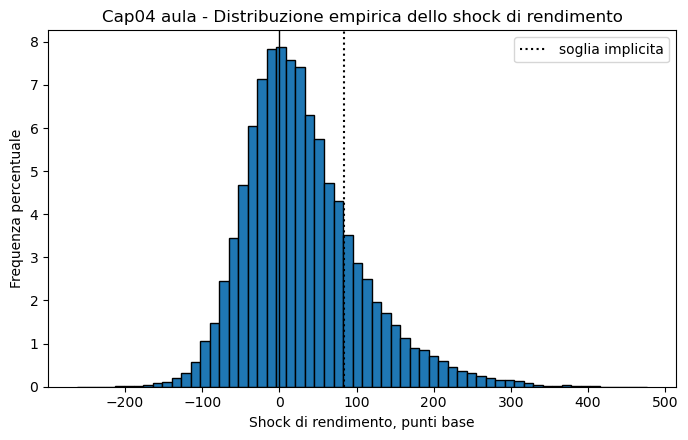

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["delta_y_bp"], bins=60, weights=np.ones(n) / n * 100, edgecolor="black")
ax.axvline(delta_y_star * 10_000, color="black", linestyle=":", label="soglia implicita")
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlabel("Shock di rendimento, punti base")
ax.set_ylabel("Frequenza percentuale")
ax.set_title("Cap04 aula - Distribuzione empirica dello shock di rendimento")
ax.legend()
fig.tight_layout()
fig_path_shock = GRAPHICS_DIR / "Cap04_aula_hist_shock_rendimento.png"
fig.savefig(fig_path_shock, dpi=200)
fig_path_shock

WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_aula_hist_perdita.png')

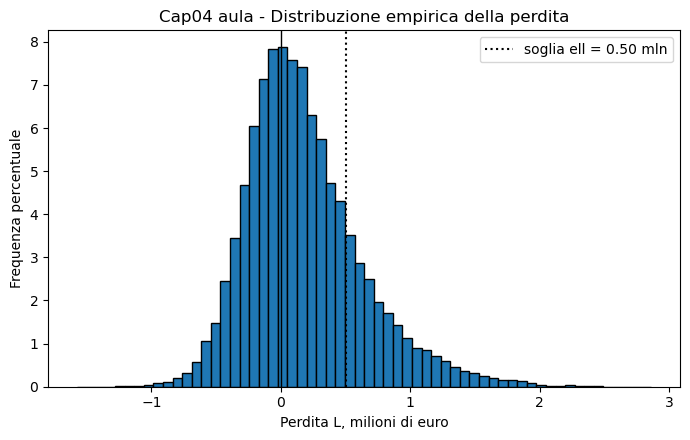

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
L_mln = df["L"] / 1_000_000
ell_mln = ell / 1_000_000
ax.hist(L_mln, bins=60, weights=np.ones(n) / n * 100, edgecolor="black")
ax.axvline(ell_mln, color="black", linestyle=":", label=f"soglia ell = {ell_mln:.2f} mln")
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlabel("Perdita L, milioni di euro")
ax.set_ylabel("Frequenza percentuale")
ax.set_title("Cap04 aula - Distribuzione empirica della perdita")
ax.legend()
fig.tight_layout()
fig_path_hist_L = GRAPHICS_DIR / "Cap04_aula_hist_perdita.png"
fig.savefig(fig_path_hist_L, dpi=200)
fig_path_hist_L

WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_aula_ecdf_perdita.png')

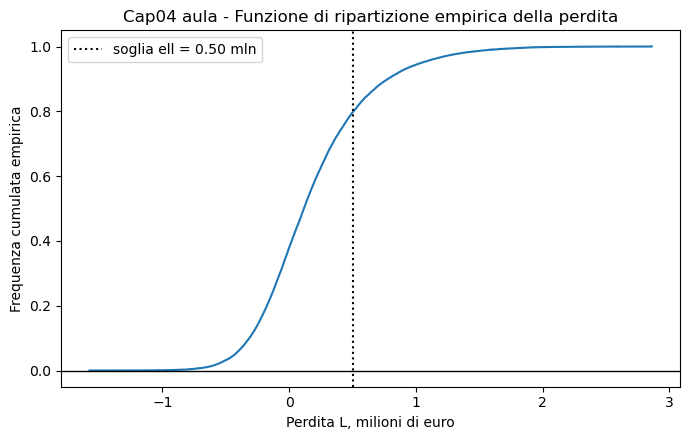

In [24]:
L_sorted = np.sort(df["L"].to_numpy())
L_sorted_mln = L_sorted / 1_000_000
ecdf = np.arange(1, n + 1) / n
assert np.all(np.diff(ecdf) >= 0), "La ECDF non e' non decrescente."

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.step(L_sorted_mln, ecdf, where="post")
ax.axvline(ell / 1_000_000, color="black", linestyle=":", label=f"soglia ell = {ell / 1_000_000:.2f} mln")
ax.axhline(0, color="black", linewidth=1.0)
ax.set_xlabel("Perdita L, milioni di euro")
ax.set_ylabel("Frequenza cumulata empirica")
ax.set_title("Cap04 aula - Funzione di ripartizione empirica della perdita")
ax.legend()
fig.tight_layout()
fig_path_ecdf = GRAPHICS_DIR / "Cap04_aula_ecdf_perdita.png"
fig.savefig(fig_path_ecdf, dpi=200)
fig_path_ecdf

## Tappa 5 - Analisi condizionata e valore atteso totale

Per ciascun evento $A_g$ si stima:

$$
\widehat{\mathbb{E}}[L\mid A_g].
$$

La variabile condizionata rispetto alla sigma-algebra informativa e':

$$
\widehat{\mathbb{E}}[L\mid\mathcal{G}]
=
\sum_{g=1}^{3}
\widehat{\mathbb{E}}[L\mid A_g]\mathbf{1}_{A_g}.
$$

Nel campione simulato si verifica inoltre:

$$
\widehat{\mathbb{E}}[L]
=
\sum_{g=1}^{3}
\widehat{\mathbb{P}}(A_g)
\widehat{\mathbb{E}}[L\mid A_g],
$$

salvo arrotondamenti numerici.

In [25]:
df_cond = (
    df.groupby("evento", observed=False)
    .agg(
        frequenza=("L", "size"),
        E_hat_L_cond=("L", "mean"),
        sd_L_cond=("L", "std"),
        prob_L_gt_ell_cond=("L", lambda x: (x > ell).mean()),
        q05_L_cond=("L", lambda x: x.quantile(0.05)),
        q50_L_cond=("L", lambda x: x.quantile(0.50)),
        q95_L_cond=("L", lambda x: x.quantile(0.95)),
    )
    .reindex(eventi)
    .reset_index()
)
df_cond["frequenza_relativa"] = df_cond["frequenza"] / n
df_cond["descrizione"] = df_cond["evento"].map(descrizioni)
df_cond["E_L_cond_teorica"] = D * V0 * mu
df_cond["ordine_atteso"] = df_cond["evento"].map({"A1": 1, "A2": 2, "A3": 3})

assert (df_cond["frequenza"] > 0).all(), "Ogni evento deve avere numerosita' positiva."
assert df_cond.sort_values("ordine_atteso")["E_hat_L_cond"].is_monotonic_increasing, (
    "Le medie condizionate non sono ordinate come previsto dalla calibrazione."
)

cond_map = df_cond.set_index("evento")["E_hat_L_cond"]
df["E_L_cond_G_hat"] = df["evento"].map(cond_map)

media_globale = df["L"].mean()
media_ricomposta = (df_cond["frequenza_relativa"] * df_cond["E_hat_L_cond"]).sum()
differenza_media = media_globale - media_ricomposta

df_verifica_totale = pd.DataFrame({
    "quantita": [
        "media campionaria globale",
        "media ricomposta con frequenze empiriche",
        "differenza",
        "media teorica parametrica",
    ],
    "valore": [
        media_globale,
        media_ricomposta,
        differenza_media,
        D * V0 * np.sum(p * mu),
    ],
})

assert np.isclose(media_globale, media_ricomposta), "La media ricomposta non coincide con la media globale."
assert df.groupby("evento")["E_L_cond_G_hat"].nunique().max() == 1, (
    "La variabile E[L|G] stimata non e' costante su ciascun blocco."
)

display(stile_tabella(
    df_cond,
    {
        "frequenza": "{:,.0f}",
        "E_hat_L_cond": "{:,.0f}",
        "sd_L_cond": "{:,.0f}",
        "prob_L_gt_ell_cond": "{:.4f}",
        "q05_L_cond": "{:,.0f}",
        "q50_L_cond": "{:,.0f}",
        "q95_L_cond": "{:,.0f}",
        "frequenza_relativa": "{:.4f}",
        "E_L_cond_teorica": "{:,.0f}",
    },
))
stile_tabella(df_verifica_totale, {"valore": "{:,.0f}"})

,evento,frequenza,E_hat_L_cond,sd_L_cond,prob_L_gt_ell_cond,q05_L_cond,q50_L_cond,q95_L_cond,frequenza_relativa,descrizione,E_L_cond_teorica,ordine_atteso
0,A1,"17,418","-57,804","240,047",0.0095,"-453,307","-57,894","335,174",0.3484,Disinflazione ordinata,"-60,000",1
1,A2,"22,576","181,993","361,850",0.1899,"-410,845","182,728","780,940",0.4515,Inflazione persistente,"180,000",2
2,A3,"10,006","605,231","596,656",0.5720,"-379,016","608,310","1,580,256",0.2001,Repricing severo,"600,000",3


,quantita,valore
0,media campionaria globale,"183,156"
1,media ricomposta con frequenze empiriche,"183,156"
2,differenza,0
3,media teorica parametrica,"180,000"


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_aula_medie_condizionate.png')

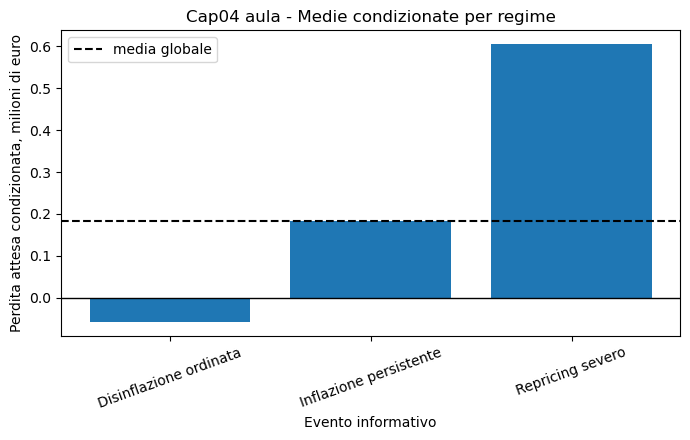

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(df_cond["descrizione"], df_cond["E_hat_L_cond"] / 1_000_000)
ax.axhline(0, color="black", linewidth=1.0)
ax.axhline(media_globale / 1_000_000, color="black", linestyle="--", label="media globale")
ax.set_xlabel("Evento informativo")
ax.set_ylabel("Perdita attesa condizionata, milioni di euro")
ax.set_title("Cap04 aula - Medie condizionate per regime")
ax.tick_params(axis="x", rotation=20)
ax.legend()
fig.tight_layout()
fig_path_medie = GRAPHICS_DIR / "Cap04_aula_medie_condizionate.png"
fig.savefig(fig_path_medie, dpi=200)
fig_path_medie

WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_aula_distribuzioni_condizionate.png')

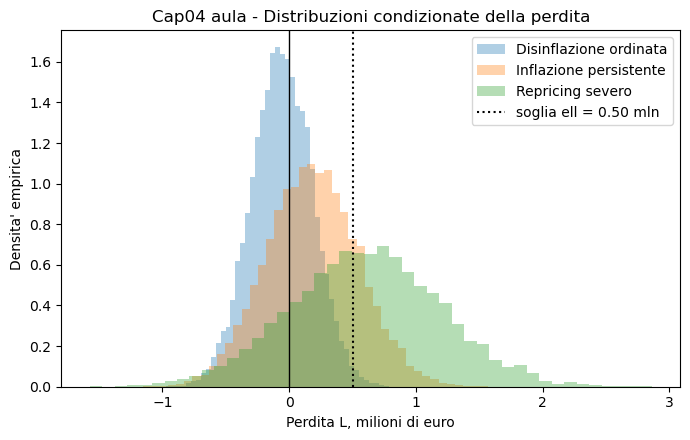

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for evento in eventi:
    dati = df.loc[df["evento"] == evento, "L"] / 1_000_000
    ax.hist(
        dati,
        bins=45,
        density=True,
        alpha=0.35,
        label=descrizioni[evento],
    )
ax.axvline(ell / 1_000_000, color="black", linestyle=":", label=f"soglia ell = {ell / 1_000_000:.2f} mln")
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlabel("Perdita L, milioni di euro")
ax.set_ylabel("Densita' empirica")
ax.set_title("Cap04 aula - Distribuzioni condizionate della perdita")
ax.legend()
fig.tight_layout()
fig_path_cond = GRAPHICS_DIR / "Cap04_aula_distribuzioni_condizionate.png"
fig.savefig(fig_path_cond, dpi=200)
fig_path_cond

## Tappa 6 - Interpretazione critica docente

Il notebook mostra che la distribuzione non condizionata della perdita nasce dalla combinazione tra frequenze dei regimi e distribuzioni condizionate degli shock di rendimento.

Nel regime $A_1$ la media condizionata puo' essere negativa: in questo caso la riduzione media dei rendimenti produce, tramite la formula di duration, un guadagno medio e quindi una perdita media negativa.

Il regime $A_2$ rappresenta una situazione intermedia, con perdita attesa positiva ma inferiore a quella del regime di repricing severo.

Il regime $A_3$ deve essere letto come il blocco informativo con perdita attesa piu' elevata e maggiore dispersione. L'informazione di regime non elimina l'incertezza residua: anche condizionando a $A_g$, lo shock resta aleatorio e la perdita ha una distribuzione.

La probabilita' globale $\widehat{\mathbb{P}}(L>\ell)$ e' una probabilita' non condizionata, ottenuta sull'intero campione simulato. Non deve essere interpretata come probabilita' valida in ciascun regime.

La verifica del valore atteso totale e' una verifica campionaria della coerenza della simulazione. La proprieta' teorica resta:

$$
\mathbb{E}[L]
=
\sum_{g=1}^{3}
\mathbb{P}(A_g)\mathbb{E}[L\mid A_g].
$$

## Limiti del modello

Il caso ha finalita' didattica e non produce una misura gestionale completa del rischio di tasso.

I principali limiti sono:

1. uso dell'approssimazione lineare di duration;
2. assenza della convessita';
3. assenza di una curva dei rendimenti per scadenza;
4. assenza di movimenti non paralleli della curva;
5. assenza di flussi cedolari espliciti;
6. assenza di rischio di credito e rischio di liquidita';
7. assenza di dinamica multiperiodale;
8. parametri stilizzati, non stimati da dati reali.

La simulazione deve essere letta come strumento per rendere osservabili distribuzioni, condizionamento e valore atteso totale, non come previsione dei tassi.

## Esportazione degli output

Le tabelle principali vengono salvate in `output_Lez04_Aula/`, mentre i grafici vengono salvati nella cartella comune `graphics/`.

In [29]:
# La cella di esportazione assume che le tappe precedenti siano state eseguite.
# Se Tappa 5 non e' stata eseguita, ricostruisce le tabelle condizionate
# necessarie al salvataggio, ma lascia all'aula l'esecuzione dei grafici.
if "df_cond" not in globals() or "df_verifica_totale" not in globals():
    df_cond = (
        df.groupby("evento", observed=False)
        .agg(
            frequenza=("L", "size"),
            E_hat_L_cond=("L", "mean"),
            sd_L_cond=("L", "std"),
            prob_L_gt_ell_cond=("L", lambda x: (x > ell).mean()),
            q05_L_cond=("L", lambda x: x.quantile(0.05)),
            q50_L_cond=("L", lambda x: x.quantile(0.50)),
            q95_L_cond=("L", lambda x: x.quantile(0.95)),
        )
        .reindex(eventi)
        .reset_index()
    )
    df_cond["frequenza_relativa"] = df_cond["frequenza"] / n
    df_cond["descrizione"] = df_cond["evento"].map(descrizioni)
    df_cond["E_L_cond_teorica"] = D * V0 * mu
    df_cond["ordine_atteso"] = df_cond["evento"].map({"A1": 1, "A2": 2, "A3": 3})

    cond_map = df_cond.set_index("evento")["E_hat_L_cond"]
    df["E_L_cond_G_hat"] = df["evento"].map(cond_map)

    media_globale = df["L"].mean()
    media_ricomposta = (df_cond["frequenza_relativa"] * df_cond["E_hat_L_cond"]).sum()
    differenza_media = media_globale - media_ricomposta
    df_verifica_totale = pd.DataFrame({
        "quantita": [
            "media campionaria globale",
            "media ricomposta con frequenze empiriche",
            "differenza",
            "media teorica parametrica",
        ],
        "valore": [
            media_globale,
            media_ricomposta,
            differenza_media,
            D * V0 * np.sum(p * mu),
        ],
    })

tabelle_output = {
    "Lez04_Aula_parametri_finanziari.csv": df_parametri_finanziari,
    "Lez04_Aula_eventi.csv": df_eventi,
    "Lez04_Aula_parametri_condizionati.csv": df_parametri_condizionati,
    "Lez04_Aula_frequenze_eventi.csv": df_frequenze,
    "Lez04_Aula_controllo_shock.csv": df_controllo_shock,
    "Lez04_Aula_statistiche_perdita.csv": df_stat_L,
    "Lez04_Aula_quantili_perdita.csv": df_quantili_L,
    "Lez04_Aula_probabilita_soglia.csv": df_prob_soglia,
    "Lez04_Aula_medie_condizionate.csv": df_cond,
    "Lez04_Aula_verifica_valore_atteso_totale.csv": df_verifica_totale,
}

for nome_file, tabella in tabelle_output.items():
    tabella.to_csv(OUTPUT_DIR / nome_file, index=False)

df.head(1000).to_csv(OUTPUT_DIR / "Lez04_Aula_dataset_preview.csv", index=False)

grafici_output = [
    name
    for name in [
        "fig_path_shock",
        "fig_path_hist_L",
        "fig_path_ecdf",
        "fig_path_medie",
        "fig_path_cond",
    ]
    if name in globals()
]

df_output = pd.DataFrame({
    "tipo": ["tabella"] * len(tabelle_output) + ["grafico"] * len(grafici_output),
    "percorso": [str(OUTPUT_DIR / nome) for nome in tabelle_output] + [str(globals()[name]) for name in grafici_output],
})

assert all((OUTPUT_DIR / nome).exists() and (OUTPUT_DIR / nome).stat().st_size > 0 for nome in tabelle_output)
assert all(globals()[name].exists() and globals()[name].stat().st_size > 0 for name in grafici_output)

df_output

,tipo,percorso
0,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
1,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
2,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
3,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
4,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
5,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
6,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
7,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
8,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
9,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\Le...
